# Bài toán 4: Dự đoán Thời gian Chuyến xe (Trip Duration)

## Mục đích
- Dự đoán thời gian chuyến xe (trip_duration) dựa trên các đặc trưng
- Sử dụng output từ các bài toán trước: `cluster_id`, `behavior_cluster`
- So sánh nhiều mô hình ML Regressor và chọn mô hình tốt nhất

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import gc, time
try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    PSUTIL_AVAILABLE = False

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, HalvingRandomSearchCV
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error,
)
from xgboost import XGBRegressor

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load dữ liệu và tái tạo các features từ bài toán trước

In [2]:
# Load processed data
df = pd.read_csv('../data/raw/yellow_tripdata_2016-03_processed.csv')

print(f"✅ Dữ liệu loaded: {df.shape}")
print(f"Các cột trong dataset: {df.columns.tolist()}")
print(f"\nTrip duration stats:")
print(df['trip_duration'].describe())

✅ Dữ liệu loaded: (11411918, 25)
Các cột trong dataset: ['Unnamed: 0', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'fare_amount', 'trip_duration', 'speed', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'time_of_day', 'is_peak_hour', 'is_credit_card', 'total_income', 'location_cluster', 'fare_per_miles', 'fare_per_min', 'traffic_index', 'traffic_level', 'behavior_cluster']

Trip duration stats:
count    1.141192e+07
mean     7.471010e+02
std      4.733584e+02
min      6.100000e+01
25%      3.900000e+02
50%      6.350000e+02
75%      9.950000e+02
max      2.655000e+03
Name: trip_duration, dtype: float64


## 3. Tái tạo cluster_id (từ bài toán 2)

In [3]:
# Sử dụng output từ bài toán cluster
print("Sử dụng cluster_id từ output của bài toán cluster...")

# File yellow_tripdata_2016-03_processed.csv đã được tạo từ cluster.ipynb
# và chứa cột location_cluster
if 'location_cluster' in df.columns:
    df['cluster_id'] = df['location_cluster'].copy()
    df = df.drop('location_cluster', axis=1)
    print(f"✅ Sử dụng location_cluster từ output bài toán cluster")
elif 'cluster_id' not in df.columns:
    raise ValueError('Không tìm thấy cột cluster_id hoặc location_cluster trong dữ liệu.')

print(f"✅ Cluster_id loaded")
print(f"Cluster distribution:\n{df['cluster_id'].value_counts().sort_index()}")


Sử dụng cluster_id từ output của bài toán cluster...
✅ Sử dụng location_cluster từ output bài toán cluster
✅ Cluster_id loaded
Cluster distribution:
cluster_id
-1      454574
 0    10668458
 1      238536
 2       27468
 3       10107
 4       12775
Name: count, dtype: int64


## 4. Sử dụng output của behavior_cluster (từ bài toán cluster_behavior)

In [4]:
# Behavior cluster đã có sẵn trong file processed — kiểm tra và chuẩn hoá
if 'behavior_cluster' not in df.columns:
    raise ValueError("Không tìm thấy cột behavior_cluster.")

# Cảnh báo nếu có giá trị thiếu
missing = df['behavior_cluster'].isna().sum() if 'behavior_cluster' in df.columns else 0
if missing > 0:
    print("f")

# Dùng nullable integer type để giữ NA nếu cần
try:
    df['behavior_cluster'] = df['behavior_cluster'].astype('Int64')
except Exception:
    df['behavior_cluster'] = pd.to_numeric(df['behavior_cluster'], errors='coerce').astype('Int64')

print("✅ behavior_cluster có sẵn — unique clusters:")

✅ behavior_cluster có sẵn — unique clusters:


## 5. Chuẩn bị Features cho Regressor

In [5]:
# Chọn features để dự đoán trip_duration
# Ưu tiên các biến đầu vào không gây leakage và có ý nghĩa trực tiếp cho thời gian chuyến xe
feature_cols = [
    'trip_distance',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'cluster_id',
    'behavior_cluster',
    'passenger_count'
]

# Kiểm tra features có sẵn
available_features = [f for f in feature_cols if f in df.columns]
print(f"Features sử dụng ({len(available_features)}): {available_features}")

X = df[available_features].copy()
y = df['trip_duration'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature stats:")
print(X.describe())

Features sử dụng (8): ['trip_distance', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'cluster_id', 'behavior_cluster', 'passenger_count']

X shape: (11411918, 8)
y shape: (11411918,)

Feature stats:
       trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
count   1.141192e+07      1.141192e+07     1.141192e+07       1.141192e+07   
mean    2.433433e+00     -7.397761e+01     4.075276e+01      -7.397535e+01   
std     2.267391e+00      2.712710e-02     2.407487e-02       2.747731e-02   
min     1.100000e-01     -7.414575e+01     4.057748e+01      -7.414951e+01   
25%     1.000000e+00     -7.399213e+01     4.073857e+01      -7.399142e+01   
50%     1.650000e+00     -7.398216e+01     4.075448e+01      -7.398017e+01   
75%     2.900000e+00     -7.396909e+01     4.076815e+01      -7.396438e+01   
max     1.326000e+01     -7.370239e+01     4.091751e+01      -7.370040e+01   

       dropoff_latitude    cluster_id  behavior_cluster  passen

## 6. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget distribution:")
print(f"Train - Mean: {y_train.mean():.2f}s, Std: {y_train.std():.2f}s")
print(f"Test  - Mean: {y_test.mean():.2f}s, Std: {y_test.std():.2f}s")

Training set: (9129534, 8)
Test set: (2282384, 8)

Target distribution:
Train - Mean: 747.20s, Std: 473.30s
Test  - Mean: 746.72s, Std: 473.59s


## 7. Định nghĩa các mô hình Regressor

In [7]:
# Định nghĩa các mô hình với thông tin về scaling requirement
models = {
    'Random Forest': (RandomForestRegressor(n_estimators=100, max_depth=15, 
                                             random_state=42, n_jobs=-1), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      learning_rate=0.1, random_state=42), False),
    'XGBoost': (XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                             random_state=42, n_jobs=-1, tree_method='hist', verbosity=0), False)
}

print(f"✅ {len(models)} mô hình đã được định nghĩa")
for name in models.keys():
    print(f"  - {name}")

✅ 3 mô hình đã được định nghĩa
  - Random Forest
  - Gradient Boosting
  - XGBoost


## 8. Chuẩn bị Scaler (cho các mô hình yêu cầu scaling)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dữ liệu đã được scaled")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

✅ Dữ liệu đã được scaled
X_train_scaled shape: (9129534, 8)
X_test_scaled shape: (2282384, 8)


## 9. Training và Evaluation Models

In [9]:
results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("="*80)
print("TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH")
print("="*80)

for name, (model, needs_scaling) in models.items():
    print(f"\n📊 Training {name}...", end=' ', flush=True)
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Metrics on test set
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    
    # Cross-validation (use parallel workers)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, 
                                  scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    results[name] = {
        'model': model,
        'scaled': needs_scaling,
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2,
        'test_mape': mape,
        'cv_rmse': cv_rmse,
        'cv_rmse_std': np.sqrt(cv_scores.std()),
        'y_pred': y_pred_test
    }
    
    print(f"✅")
    print(f"  RMSE: {rmse:.2f}s | MAE: {mae:.2f}s | R²: {r2:.4f} | MAPE: {mape:.2%}")
    print(f"  CV RMSE: {cv_rmse:.2f}s (±{np.sqrt(cv_scores.std()):.2f}s)")

print("\n" + "="*80)
print("✅ Tất cả mô hình đã được huấn luyện!")
print("="*80)

TRAINING VÀ ĐÁNH GIÁ CÁC MÔ HÌNH

📊 Training Random Forest... ✅
  RMSE: 167.03s | MAE: 113.62s | R²: 0.8756 | MAPE: 16.20%
  CV RMSE: 167.22s (±6.92s)

📊 Training Gradient Boosting... ✅
  RMSE: 170.91s | MAE: 116.53s | R²: 0.8698 | MAPE: 16.81%
  CV RMSE: 171.05s (±6.24s)

📊 Training XGBoost... ✅
  RMSE: 169.33s | MAE: 115.24s | R²: 0.8722 | MAPE: 16.51%
  CV RMSE: 169.45s (±6.66s)

✅ Tất cả mô hình đã được huấn luyện!


## 10. So sánh kết quả và chọn mô hình tốt nhất

In [10]:
# Tạo dataframe để so sánh các mô hình
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test MAE': [results[m]['test_mae'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Test MAPE': [results[m]['test_mape'] for m in results.keys()],
    'CV RMSE': [results[m]['cv_rmse'] for m in results.keys()],
})

# Sắp xếp theo Test RMSE
comparison_df = comparison_df.sort_values('Test RMSE').reset_index(drop=True)

print("\n📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)

# Chọn mô hình tốt nhất (theo Test RMSE)
best_model_name = comparison_df.iloc[0]['Model']
best_test_rmse = comparison_df.iloc[0]['Test RMSE']
best_test_r2 = comparison_df.iloc[0]['Test R²']

print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"  Test RMSE: {best_test_rmse:.2f}s")
print(f"  Test R²: {best_test_r2:.4f}")


📊 BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH
            Model  Train RMSE  Test RMSE   Test MAE  Test R²  Test MAPE    CV RMSE
    Random Forest  163.977607 167.027350 113.620733 0.875612   0.162032 167.224799
          XGBoost  169.293180 169.333082 115.240254 0.872154   0.165103 169.452621
Gradient Boosting  170.874762 170.909834 116.528908 0.869762   0.168084 171.052825

🏆 MÔ HÌNH TỐT NHẤT: Random Forest
  Test RMSE: 167.03s
  Test R²: 0.8756


## 10.1. Hyperparameter Tuning cho các Model

In [11]:
print("="*80)
print("HYPERPARAMETER TUNING CHO CÁC MODEL")
print("="*80)

import math

tuned_models = {}
# Reduce sample by default for memory-safety; will sample up to tuning_sample_size
tuning_sample_size = 10000
tuning_rng = np.random.default_rng(42)

# Định nghĩa tham số tuning cho mỗi model
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [8, 12, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

for model_name in models.keys():
    if model_name not in param_grids:
        print(f"⚠️ {model_name} không có tham số tuning được định nghĩa")
        continue
    
    print(f"\n🔧 Tuning {model_name}...", flush=True)
    
    # Lấy model base từ results
    base_model = results[model_name]['model']
    needs_scaling = results[model_name]['scaled']
    
    # Chọn dữ liệu scaled hay không
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test
    
    # Tuning trên một mẫu giới hạn để tránh MemoryError
    n_rows = len(X_tr)
    sample_size = min(tuning_sample_size, n_rows)
    if sample_size < n_rows:
        sample_indices = tuning_rng.choice(n_rows, size=sample_size, replace=False)
        if hasattr(X_tr, 'iloc'):
            X_tune = X_tr.iloc[sample_indices]
        else:
            X_tune = X_tr[sample_indices]
        if hasattr(y_train, 'iloc'):
            y_tune = y_train.iloc[sample_indices]
        else:
            y_tune = y_train[sample_indices]
    else:
        X_tune = X_tr
        y_tune = y_train
    
    # Convert tuning arrays to compact numpy dtypes to save memory/copy overhead
    if hasattr(X_tune, 'to_numpy'):
        X_tune_np = X_tune.to_numpy(dtype=np.float32)
    else:
        X_tune_np = np.asarray(X_tune, dtype=np.float32)
    if hasattr(y_tune, 'to_numpy'):
        y_tune_np = y_tune.to_numpy(dtype=np.float32)
    else:
        y_tune_np = np.asarray(y_tune, dtype=np.float32)

    # Choose successive halving when available for efficiency, else randomized search
    try:
        searcher = HalvingRandomSearchCV(
            estimator=base_model,
            param_distributions=param_grids[model_name],
            factor=3,
            cv=3,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            random_state=42,
            verbose=1
        )
        search_kind = 'halving'
    except Exception:
        searcher = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grids[model_name],
            n_iter=25,
            cv=3,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            pre_dispatch='2*n_jobs',
            random_state=42,
            verbose=1
        )
        search_kind = 'randomized'

    # Optional memory check before fit
    if PSUTIL_AVAILABLE:
        proc = psutil.Process()
        mem_before = proc.memory_info().rss / (1024**2)
        print(f"Memory before search ({search_kind}): {mem_before:.1f} MiB")

    t0 = time.perf_counter()
    try:
        searcher.fit(X_tune_np, y_tune_np)
    finally:
        elapsed = time.perf_counter() - t0
    
    if PSUTIL_AVAILABLE:
        mem_after = proc.memory_info().rss / (1024**2)
        print(f"Memory after search: {mem_after:.1f} MiB (Δ {mem_after-mem_before:.1f} MiB)")

    print(f"  Search kind: {search_kind} | elapsed: {elapsed:.1f}s | best_score: {searcher.best_score_}")

    # Refit model tốt nhất trên toàn bộ training split (use clone to avoid reusing search's heavy internal state)
    best_params = searcher.best_params_
    best_model_tuned = clone(base_model).set_params(**best_params)
    best_model_tuned.fit(X_tr, y_train)

    # Predictions
    y_pred_train_tuned = best_model_tuned.predict(X_tr)
    y_pred_test_tuned = best_model_tuned.predict(X_te)

    # Metrics
    train_rmse_tuned = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))
    test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))
    test_mae_tuned = mean_absolute_error(y_test, y_pred_test_tuned)
    test_r2_tuned = r2_score(y_test, y_pred_test_tuned)
    test_mape_tuned = mean_absolute_percentage_error(y_test, y_pred_test_tuned)

    tuned_models[model_name] = {
        'model': best_model_tuned,
        'scaled': needs_scaling,
        'best_params': best_params,
        'best_cv_score': np.sqrt(-searcher.best_score_),
        'train_rmse': train_rmse_tuned,
        'test_rmse': test_rmse_tuned,
        'test_mae': test_mae_tuned,
        'test_r2': test_r2_tuned,
        'test_mape': test_mape_tuned,
        'y_pred': y_pred_test_tuned
    }

    print(f"   ✅ Tuning hoàn tất for {model_name}!")
    print(f"   Best params: {best_params}")
    print(f"   CV RMSE (est): {np.sqrt(-searcher.best_score_):.2f}s")
    print(f"   Test RMSE: {test_rmse_tuned:.2f}s | MAE: {test_mae_tuned:.2f}s | R²: {test_r2_tuned:.4f}")

    # Release memory from large temporary arrays
    try:
        del X_tune, y_tune, X_tune_np, y_tune_np, searcher
    except Exception:
        pass
    gc.collect()

print("\n" + "="*80)
print("✅ Tuning hoàn tất cho tất cả các model!")
print("="*80)

HYPERPARAMETER TUNING CHO CÁC MODEL

🔧 Tuning Random Forest...
Memory before search (halving): 1402.4 MiB
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 7
min_resources_: 6
max_resources_: 10000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 36
n_resources: 6
Fitting 3 folds for each of 36 candidates, totalling 108 fits
----------
iter: 1
n_candidates: 12
n_resources: 18
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 2
n_candidates: 4
n_resources: 54
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 3
n_candidates: 2
n_resources: 162
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Memory after search: 1417.5 MiB (Δ 15.1 MiB)
  Search kind: halving | elapsed: 5.4s | best_score: -55975.24705692
   ✅ Tuning hoàn tất for Random Forest!
   Best params: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 8}
   CV RMSE (est): 236.59s
   Test RMSE: 176.7

## 10.2. So Sánh Kết Quả Trước và Sau Tuning

In [12]:
# Tạo dataframe so sánh trước và sau tuning
comparison_tuning = []

for model_name in models.keys():
    if model_name not in tuned_models:
        continue
    
    # Kết quả trước tuning
    before = comparison_df[comparison_df['Model'] == model_name].iloc[0]
    
    # Kết quả sau tuning
    after = tuned_models[model_name]
    
    comparison_tuning.append({
        'Model': model_name,
        'Before Tuning RMSE': before['Test RMSE'],
        'After Tuning RMSE': after['test_rmse'],
        'RMSE Improvement (%)': ((before['Test RMSE'] - after['test_rmse']) / before['Test RMSE'] * 100),
        'Before R²': before['Test R²'],
        'After R²': after['test_r2'],
        'R² Improvement': (after['test_r2'] - before['Test R²'])
    })

comparison_tuning_df = pd.DataFrame(comparison_tuning)

print("\n📊 BẢNG SO SÁNH KẾT QUẢ TRƯỚC VÀ SAU TUNING")
print("="*140)
print(comparison_tuning_df.to_string(index=False))
print("="*140)

# Chọn model tốt nhất sau tuning
best_tuned_model_name = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'Model']
best_tuned_rmse = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'After Tuning RMSE']
best_tuned_r2 = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'After R²']
improvement = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'RMSE Improvement (%)']

print(f"\n🏆 MÔ HÌNH TỐT NHẤT SAU TUNING: {best_tuned_model_name}")
print(f"  Test RMSE: {best_tuned_rmse:.2f}s")
print(f"  Test R²: {best_tuned_r2:.4f}")
print(f"  Cải thiện RMSE: {improvement:.2f}%")
print(f"\n  Best Hyperparameters:")
for param, value in tuned_models[best_tuned_model_name]['best_params'].items():
    print(f"    - {param}: {value}")



📊 BẢNG SO SÁNH KẾT QUẢ TRƯỚC VÀ SAU TUNING
            Model  Before Tuning RMSE  After Tuning RMSE  RMSE Improvement (%)  Before R²  After R²  R² Improvement
    Random Forest          167.027350         176.756807             -5.825068   0.875612  0.860699       -0.014913
Gradient Boosting          170.909834         180.301453             -5.495072   0.869762  0.855055       -0.014707
          XGBoost          169.333082         178.424403             -5.368898   0.872154  0.858058       -0.014096

🏆 MÔ HÌNH TỐT NHẤT SAU TUNING: Random Forest
  Test RMSE: 176.76s
  Test R²: 0.8607
  Cải thiện RMSE: -5.83%

  Best Hyperparameters:
    - n_estimators: 150
    - min_samples_split: 2
    - min_samples_leaf: 2
    - max_depth: 8


## 10.3. Visualization Kết Quả Tuning

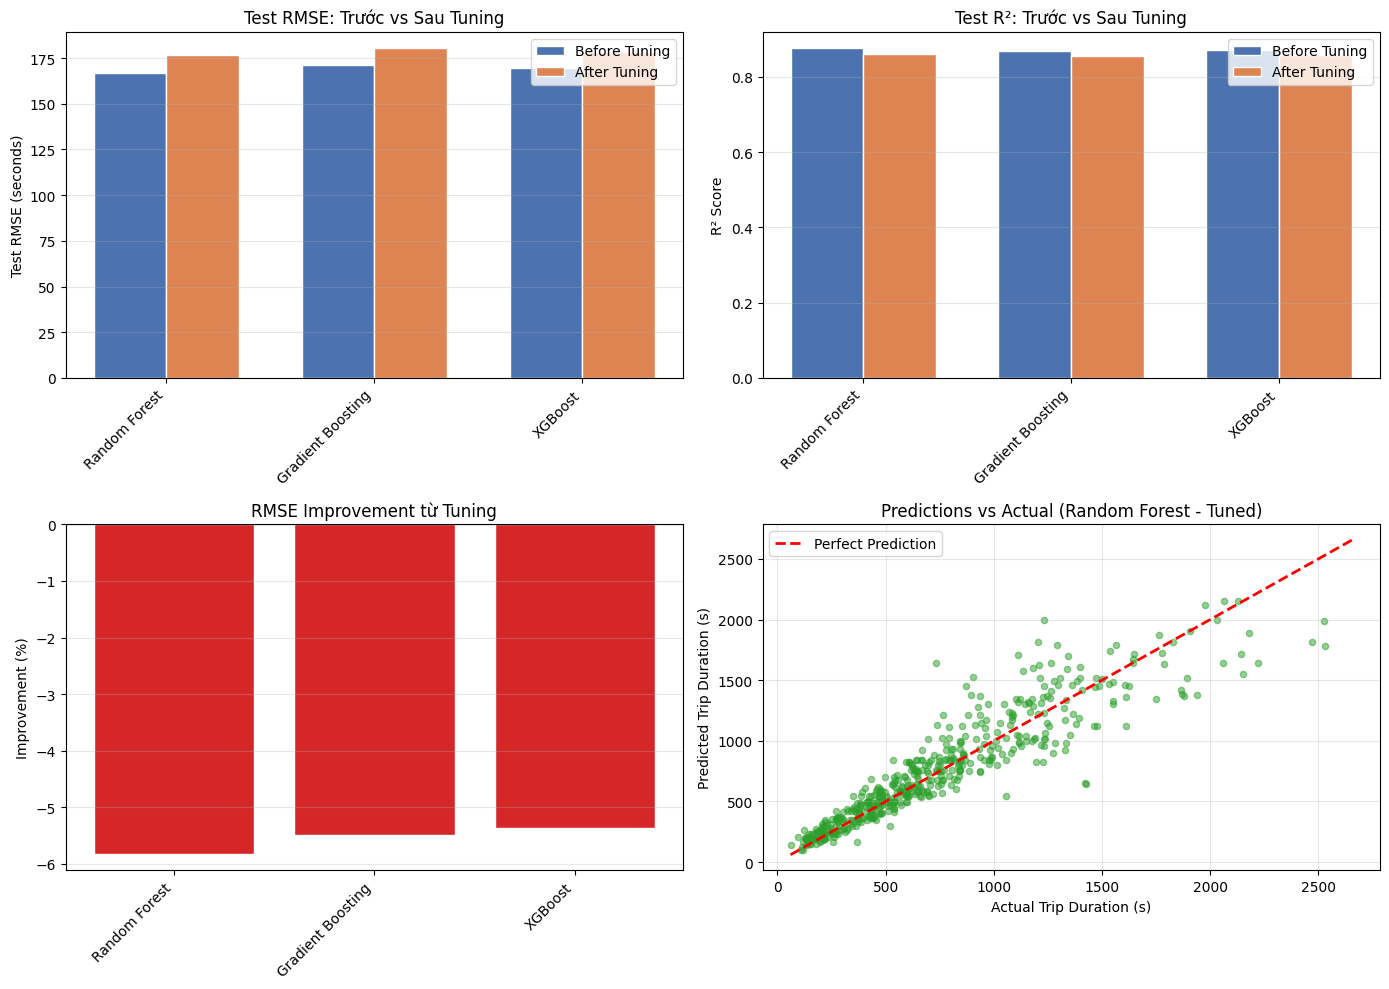

✅ Visualization saved as 'trip_duration_tuning_comparison.png'


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: RMSE Trước và Sau Tuning
models_tuning = comparison_tuning_df['Model']
x = np.arange(len(models_tuning))
width = 0.35

axes[0, 0].bar(x - width/2, comparison_tuning_df['Before Tuning RMSE'], width, 
               label='Before Tuning', color='#4C72B0', edgecolor='white')
axes[0, 0].bar(x + width/2, comparison_tuning_df['After Tuning RMSE'], width, 
               label='After Tuning', color='#DD8452', edgecolor='white')
axes[0, 0].set_ylabel('Test RMSE (seconds)')
axes[0, 0].set_title('Test RMSE: Trước vs Sau Tuning')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: R² Trước và Sau Tuning
axes[0, 1].bar(x - width/2, comparison_tuning_df['Before R²'], width, 
               label='Before Tuning', color='#4C72B0', edgecolor='white')
axes[0, 1].bar(x + width/2, comparison_tuning_df['After R²'], width, 
               label='After Tuning', color='#DD8452', edgecolor='white')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('Test R²: Trước vs Sau Tuning')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Cải thiện RMSE (%)
colors_improvement = ['#2CA02C' if x > 0 else '#D62728' for x in comparison_tuning_df['RMSE Improvement (%)']]
axes[1, 0].bar(models_tuning, comparison_tuning_df['RMSE Improvement (%)'], color=colors_improvement, edgecolor='white')
axes[1, 0].set_ylabel('Improvement (%)')
axes[1, 0].set_title('RMSE Improvement từ Tuning')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].set_xticklabels(models_tuning, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Actual vs Predicted cho best tuned model
best_tuned_model = tuned_models[best_tuned_model_name]
y_pred_best_tuned = best_tuned_model['y_pred']

n_sample = min(500, len(y_test))
axes[1, 1].scatter(y_test.iloc[:n_sample], y_pred_best_tuned[:n_sample], 
                   alpha=0.5, s=20, color='#2CA02C')
min_val = min(y_test.min(), y_pred_best_tuned.min())
max_val = max(y_test.max(), y_pred_best_tuned.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Trip Duration (s)')
axes[1, 1].set_ylabel('Predicted Trip Duration (s)')
axes[1, 1].set_title(f'Predictions vs Actual ({best_tuned_model_name} - Tuned)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_tuning_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Visualization saved as 'trip_duration_tuning_comparison.png'")


## 11. Visualize Model Performance

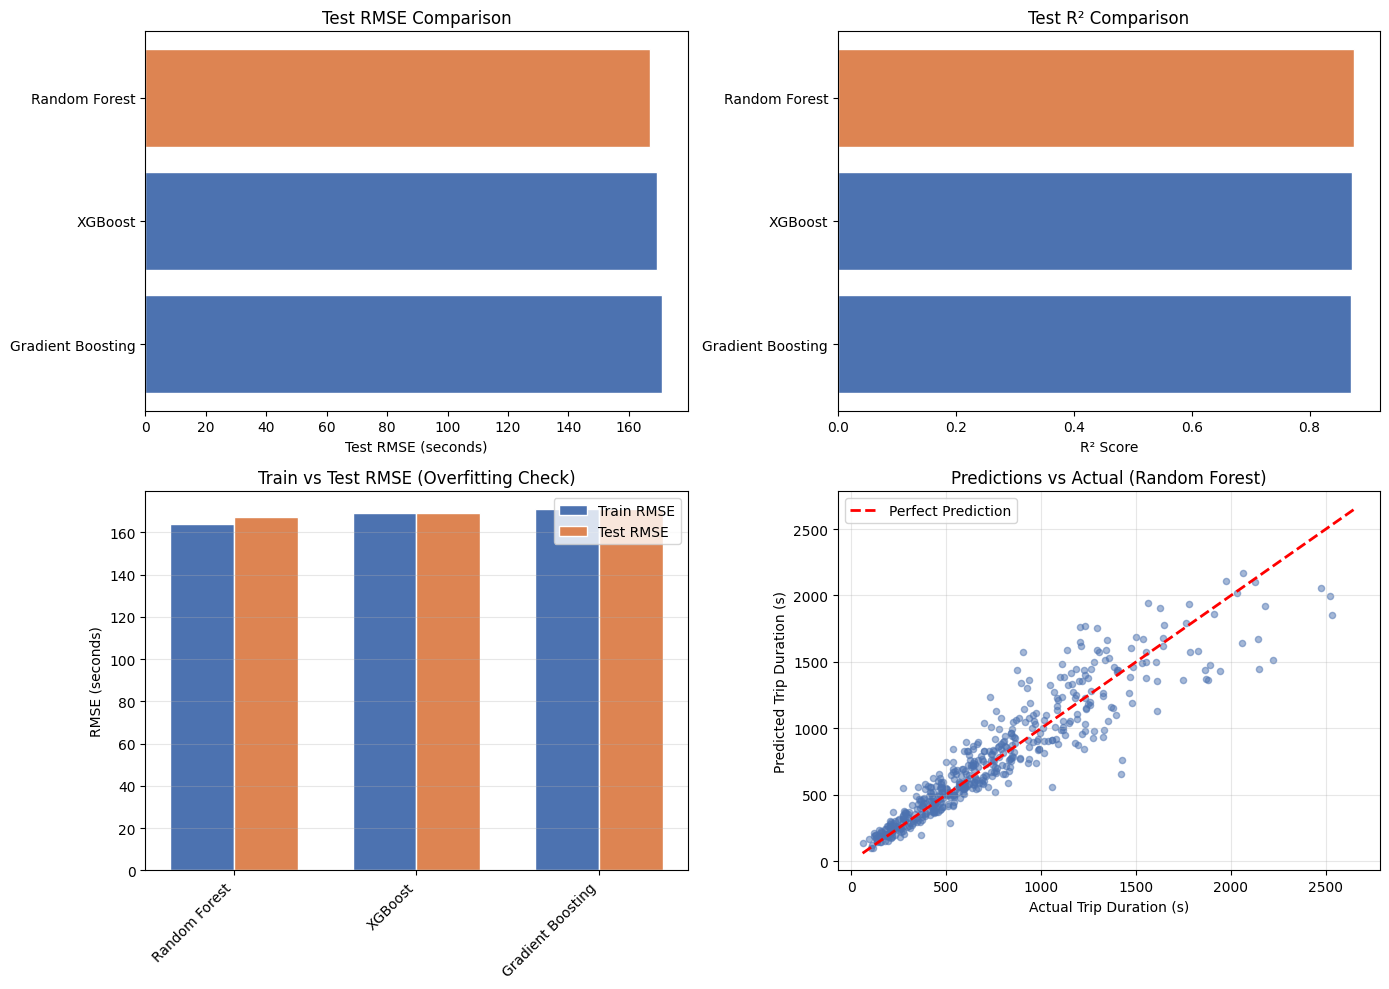

✅ Visualization saved as 'trip_duration_model_comparison.png'


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Test RMSE comparison
comparison_sorted = comparison_df.sort_values('Test RMSE')
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted['Model']]
axes[0, 0].barh(comparison_sorted['Model'], comparison_sorted['Test RMSE'], color=colors, edgecolor='white')
axes[0, 0].set_xlabel('Test RMSE (seconds)')
axes[0, 0].set_title('Test RMSE Comparison')
axes[0, 0].invert_yaxis()

# Plot 2: Test R² comparison
comparison_sorted_r2 = comparison_df.sort_values('Test R²', ascending=False)
colors = ['#DD8452' if m == best_model_name else '#4C72B0' for m in comparison_sorted_r2['Model']]
axes[0, 1].barh(comparison_sorted_r2['Model'], comparison_sorted_r2['Test R²'], color=colors, edgecolor='white')
axes[0, 1].set_xlabel('R² Score')
axes[0, 1].set_title('Test R² Comparison')
axes[0, 1].invert_yaxis()

# Plot 3: Train vs Test RMSE (overfitting check)
models_to_plot = comparison_df['Model']
x = np.arange(len(models_to_plot))
width = 0.35

axes[1, 0].bar(x - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', color='#4C72B0', edgecolor='white')
axes[1, 0].bar(x + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', color='#DD8452', edgecolor='white')
axes[1, 0].set_ylabel('RMSE (seconds)')
axes[1, 0].set_title('Train vs Test RMSE (Overfitting Check)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_to_plot, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Predictions vs Actual (Best Model)
best_model_results = results[best_model_name]
y_pred_best = best_model_results['y_pred']

# Plot first 500 predictions for clarity
n_sample = min(500, len(y_test))
axes[1, 1].scatter(y_test.iloc[:n_sample], y_pred_best[:n_sample], alpha=0.5, s=20, color='#4C72B0')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Trip Duration (s)')
axes[1, 1].set_ylabel('Predicted Trip Duration (s)')
axes[1, 1].set_title(f'Predictions vs Actual ({best_model_name})')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trip_duration_model_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

print("✅ Visualization saved as 'trip_duration_model_comparison.png'")

## 12. Dự đoán Trip Duration cho toàn bộ Dataset

In [15]:
print(f"Dùng mô hình {best_tuned_model_name} (tuned) để dự đoán toàn bộ dataset...")

best_model = tuned_models[best_tuned_model_name]['model']
best_model_needs_scaling = tuned_models[best_tuned_model_name]['scaled']

# Prepare full data
X_full = df[available_features].copy()
if best_model_needs_scaling:
    X_full_scaled = scaler.transform(X_full)
    y_pred_full = best_model.predict(X_full_scaled)
else:
    y_pred_full = best_model.predict(X_full)

# Thêm cột prediction vào dataframe
df['predicted_trip_duration'] = y_pred_full

print(f"✅ Dự đoán hoàn tất!")
print(f"\nPredicted trip_duration statistics:")
print(df['predicted_trip_duration'].describe())
print(f"\nActual vs Predicted:")
print(f"  Actual mean: {df['trip_duration'].mean():.2f}s")
print(f"  Predicted mean: {df['predicted_trip_duration'].mean():.2f}s")
print(f"\nSample predictions:")
sample_df = df[['trip_distance', 'behavior_cluster', 'cluster_id', 'trip_duration', 'predicted_trip_duration']].head(10)
print(sample_df)


Dùng mô hình Random Forest (tuned) để dự đoán toàn bộ dataset...
✅ Dự đoán hoàn tất!

Predicted trip_duration statistics:
count    1.141192e+07
mean     7.471219e+02
std      4.383286e+02
min      7.680064e+01
25%      4.119724e+02
50%      6.405124e+02
75%      1.011360e+03
max      2.560649e+03
Name: predicted_trip_duration, dtype: float64

Actual vs Predicted:
  Actual mean: 747.10s
  Predicted mean: 747.12s

Sample predictions:
   trip_distance  behavior_cluster  cluster_id  trip_duration  \
0           2.50                 2           0          475.0   
1           2.90                 2           0          666.0   
2           6.20                 1          -1          963.0   
3           0.70                 0           0          299.0   
4           7.18                 1           0         1445.0   
5           0.54                 3           0          122.0   
6           1.70                 3           0          467.0   
7           1.10                 2          

## 13. Lưu kết quả

In [16]:
# Lưu dataframe với predictions
output_path = '../data/raw/taxi_with_predictions.csv'

# Chọn columns để lưu
save_cols = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'trip_distance', 'passenger_count',
    'trip_duration', 'predicted_trip_duration',
    'cluster_id', 'rush_hour'
]

save_cols = [c for c in save_cols if c in df.columns]
df_export = df[save_cols].copy()

df_export.to_csv(output_path, index=False)
print(f"✅ Kết quả lưu vào: {output_path}")
print(f"   Số dòng: {len(df_export)}")
print(f"   Số cột: {len(df_export.columns)}")

# Lưu model evaluation report
report_path = '../data/raw/trip_duration_model_report.txt'
with open(report_path, 'w') as f:
    f.write("=" * 120 + "\n")
    f.write("TRIP DURATION PREDICTION - MODEL EVALUATION REPORT (WITH HYPERPARAMETER TUNING)\n")
    f.write("=" * 120 + "\n\n")
    
    f.write("🏆 BEST MODEL AFTER TUNING\n")
    f.write("-" * 120 + "\n")
    f.write(f"Model Name: {best_tuned_model_name}\n")
    f.write(f"Test RMSE: {best_tuned_rmse:.2f} seconds\n")
    f.write(f"Test MAE: {tuned_models[best_tuned_model_name]['test_mae']:.2f} seconds\n")
    f.write(f"Test R²: {best_tuned_r2:.4f}\n")
    f.write(f"Test MAPE: {tuned_models[best_tuned_model_name]['test_mape']:.2%}\n")
    f.write(f"RMSE Improvement: {improvement:.2f}%\n\n")
    
    f.write("Best Hyperparameters:\n")
    for param, value in tuned_models[best_tuned_model_name]['best_params'].items():
        f.write(f"  - {param}: {value}\n")
    f.write("\n")
    
    f.write("=" * 120 + "\n")
    f.write("ALL MODELS COMPARISON (BEFORE AND AFTER TUNING)\n")
    f.write("-" * 120 + "\n")
    f.write(comparison_tuning_df.to_string(index=False))
    f.write("\n\n")
    
    f.write("=" * 120 + "\n")
    f.write("INITIAL MODELS EVALUATION\n")
    f.write("-" * 120 + "\n")
    f.write(comparison_df.to_string(index=False))
    f.write("\n")

print(f"✅ Report lưu vào: {report_path}")


✅ Kết quả lưu vào: ../data/raw/taxi_with_predictions.csv
   Số dòng: 11411918
   Số cột: 11
✅ Report lưu vào: ../data/raw/trip_duration_model_report.txt


## 14. Tóm tắt kết quả

In [17]:
print("\n" + "="*100)
print("📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION (VỚI HYPERPARAMETER TUNING)")
print("="*100)

print(f"\n✅ BƯỚC 1: DATA PREPARATION")
print(f"   - Loaded data: {len(df)} records")
print(f"   - Cluster ID: {df['cluster_id'].nunique()} clusters (từ bài toán cluster)")
print(f"   - Behavior cluster: {df['behavior_cluster'].nunique()} clusters (từ bài toán cluster_behavior)")
print(f"   - Target variable (trip_duration): {df['trip_duration'].min():.0f}s - {df['trip_duration'].max():.0f}s")

print(f"\n✅ BƯỚC 2: FEATURE ENGINEERING")
print(f"   - Total features used: {len(available_features)}")
print(f"   - Features: {', '.join(available_features)}")

print(f"\n✅ BƯỚC 3: INITIAL MODEL TRAINING & COMPARISON")
print(f"   - Total models trained: {len(models)}")
print(f"   - Train/Test split: 80/20")
print(f"   - Cross-validation: 5-Fold (parallel where supported)")
print(f"   - Models tuned:")
for model in models.keys():
    rmse = comparison_df[comparison_df['Model'] == model]['Test RMSE'].values[0]
    print(f"      - {model}: RMSE={rmse:.2f}s")

print(f"\n✅ BƯỚC 4: HYPERPARAMETER TUNING")
print(f"   - Using memory-aware search: HalvingRandomSearchCV (preferred) or RandomizedSearchCV")
print(f"   - Tuning sample size (max): {tuning_sample_size} rows; dtype=float32 for tuning arrays")
print(f"   - Search settings: cv=3, parallel jobs enabled (n_jobs=-1), successive halving when available")
print(f"   - Kết quả tuning:")
for model_name in models.keys():
    if model_name in tuned_models:
        before_rmse = comparison_df[comparison_df['Model'] == model_name]['Test RMSE'].values[0]
        after_rmse = tuned_models[model_name]['test_rmse']
        improvement_pct = ((before_rmse - after_rmse) / before_rmse * 100)
        print(f"      {model_name}:")
        print(f"        - Before: {before_rmse:.2f}s → After: {after_rmse:.2f}s (Improvement: {improvement_pct:.2f}%)")

best_improvement = comparison_tuning_df.loc[comparison_tuning_df['After Tuning RMSE'].idxmin(), 'RMSE Improvement (%)']

print(f"\n✅ BƯỚC 5: MODEL SELECTION (AFTER TUNING)")
print(f"   🏆 BEST MODEL: {best_tuned_model_name}")
print(f"      - Test RMSE: {best_tuned_rmse:.2f} seconds")
print(f"      - Test MAE: {tuned_models[best_tuned_model_name]['test_mae']:.2f} seconds")
print(f"      - Test R²: {best_tuned_r2:.4f}")
print(f"      - Test MAPE: {tuned_models[best_tuned_model_name]['test_mape']:.2%}")
print(f"      - Total RMSE Improvement: {best_improvement:.2f}%")

print(f"\n✅ BƯỚC 6: FINAL PREDICTIONS")
print(f"   - Predicted trip_duration for all {len(df)} records")
print(f"   - Prediction range: {df['predicted_trip_duration'].min():.0f}s - {df['predicted_trip_duration'].max():.0f}s")
print(f"   - Mean prediction: {df['predicted_trip_duration'].mean():.2f}s")

print(f"\n✅ BƯỚC 7: OUTPUT FILES")
print(f"   - Data with predictions: {output_path}")
print(f"   - Model evaluation report: {report_path}")
print(f"   - Visualizations:")
print(f"     * trip_duration_model_comparison.png")
print(f"     * trip_duration_tuning_comparison.png")

print("\n" + "="*100)
print("✅ Hoàn tất bài toán dự đoán Trip Duration với Hyperparameter Tuning!")
print("="*100)



📋 TÓM TẮT KẾT QUẢ - DỰ ĐOÁN TRIP DURATION (VỚI HYPERPARAMETER TUNING)

✅ BƯỚC 1: DATA PREPARATION
   - Loaded data: 11411918 records
   - Cluster ID: 6 clusters (từ bài toán cluster)
   - Behavior cluster: 4 clusters (từ bài toán cluster_behavior)
   - Target variable (trip_duration): 61s - 2655s

✅ BƯỚC 2: FEATURE ENGINEERING
   - Total features used: 8
   - Features: trip_distance, pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude, cluster_id, behavior_cluster, passenger_count

✅ BƯỚC 3: INITIAL MODEL TRAINING & COMPARISON
   - Total models trained: 3
   - Train/Test split: 80/20
   - Cross-validation: 5-Fold (parallel where supported)
   - Models tuned:
      - Random Forest: RMSE=167.03s
      - Gradient Boosting: RMSE=170.91s
      - XGBoost: RMSE=169.33s

✅ BƯỚC 4: HYPERPARAMETER TUNING
   - Using memory-aware search: HalvingRandomSearchCV (preferred) or RandomizedSearchCV
   - Tuning sample size (max): 10000 rows; dtype=float32 for tuning arrays
   - Search